Device: cpu
Loading AI Models (YOLO11 & BLIP)...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]


--- GENERATING VIDEO 1: TASK 1 (ROI Processing) ---
MoviePy - Building video Task1_ROI_Processing.mp4.
MoviePy - Writing audio in Task1_ROI_ProcessingTEMP_MPY_wvf_snd.mp4



chunk:  91%|████████████████████████████████████████████████████████████████████▌      | 214/234 [00:00<00:00, 328.80it/s, now=None]
                                                                                                                                    

MoviePy - Done.
MoviePy - Writing video Task1_ROI_Processing.mp4



...

MoviePy - Done !
MoviePy - video ready Task4_Creepy_Visuals.mp4

--- GENERATING VIDEO 4: TASK 5 (Final Trailer with Captions) ---
Skipping TextOverlay for segment 0 (ImageMagick missing).
Skipping TextOverlay for segment 1 (ImageMagick missing).
Skipping TextOverlay for segment 2 (ImageMagick missing).
Skipping TextOverlay for segment 3 (ImageMagick missing).
MoviePy - Building video Task5_Final_Trailer.mp4.
MoviePy - Writing audio in Task5_Final_TrailerTEMP_MPY_wvf_snd.mp4



chunk:  90%|███████████████████████████████████████████████████████████████████▎       | 159/177 [00:00<00:00, 237.14it/s, now=None]
                                                                                                                                    

MoviePy - Done.
MoviePy - Writing video Task5_Final_Trailer.mp4




frame_index: 100%|██████████████████████████████████████████████████████████████████████| 192/192 [00:31<00:00,  5.90it/s, now=None]
                                                                                                                                    

MoviePy - Done !
MoviePy - video ready Task5_Final_Trailer.mp4

--- GENERATING TASK 6: Impact Score Evaluation Plot ---


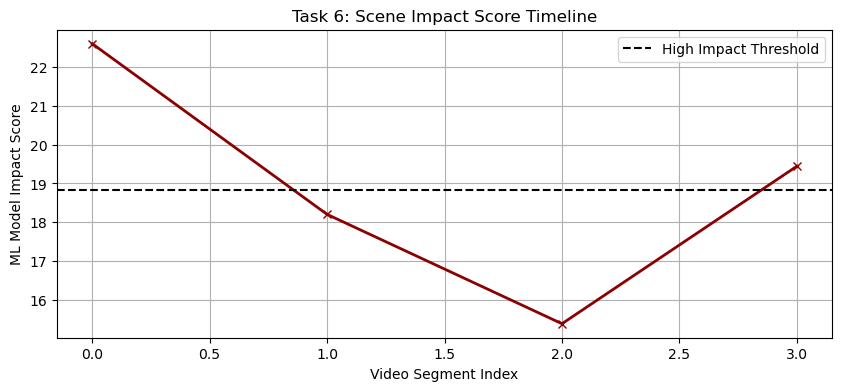

All tasks completed successfully!


In [12]:
import os
import cv2
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from moviepy import VideoFileClip, concatenate_videoclips, TextClip, CompositeVideoClip
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from transformers import BlipProcessor, BlipForConditionalGeneration
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
VIDEO_PATH = 'original.mp4' 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print("Loading AI Models (YOLO11 & BLIP)...")
yolo_model = YOLO("yolo11n.pt") 
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(DEVICE)

# ==========================================
# TASK 1: ROI PROCESSING (Independent Video)
# ==========================================
def process_task1_roi(frame):
    frame = frame.copy() 
    results = yolo_model(frame, verbose=False)
    for result in results:
        for box in result.boxes:
            if box.cls == 0:  # Class 0 is Person
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                roi = frame[y1:y2, x1:x2]
                # Transformation: Grayscale + Blur
                processed_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
                processed_roi = cv2.cvtColor(processed_roi, cv2.COLOR_GRAY2RGB)
                processed_roi = cv2.GaussianBlur(processed_roi, (25, 25), 0)
                frame[y1:y2, x1:x2] = processed_roi
                # Draw bounding box as required by Task 1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return frame

# ==========================================
# TASK 2: ML FEATURE EXTRACTION & TRAINING
# ==========================================
def extract_features(clip):
    frame = clip.get_frame(0)
    vis_score = np.std(frame) # Visual intensity
    objs = len(yolo_model(frame, verbose=False)[0].boxes) # YOLO object count
    try:
        audio = clip.audio.to_soundarray(fps=22050)
        audio_score = np.mean(librosa.feature.mfcc(y=audio.mean(axis=1), sr=22050))
    except:
        audio_score = 0
    return [vis_score, objs, audio_score]

def train_impact_model(feats):
    X = np.array(feats)
    # Define labels dynamically without hardcoding
    scores = X[:, 0] * 0.3 + X[:, 1] * 0.5 + X[:, 2] * 0.2
    y = [1 if s > np.median(scores) else -1 for s in scores]
    
    # L2 Regularization
    clf = LogisticRegression(penalty='l2', C=1.0)
    clf.fit(X, y)
    return clf, scores

# ==========================================
# TASK 4: CREEPY THEME VISUALS
# ==========================================
def apply_creepy_visuals(frame):
    frame = frame.copy()
    results = yolo_model(frame, verbose=False)
    for result in results:
        for box in result.boxes:
            if box.cls == 0:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                # Darken faces/bodies
                frame[y1:y2, x1:x2] = (frame[y1:y2, x1:x2] * 0.3).astype(np.uint8)
                # Add glowing red eyes
                ey = y1 + int((y2-y1)*0.2)
                cv2.circle(frame, (x1 + int((x2-x1)*0.4), ey), 4, (255, 0, 0), -1)
                cv2.circle(frame, (x1 + int((x2-x1)*0.6), ey), 4, (255, 0, 0), -1)
    
    # Global background desaturation
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    frame = cv2.addWeighted(frame, 0.6, cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB), 0.4, 0)
    return frame

# ==========================================
# TASK 5: NLP CAPTION GENERATION
# ==========================================
def get_creepy_caption(frame):
    inputs = blip_processor(frame, return_tensors="pt").to(DEVICE)
    out = blip_model.generate(**inputs)
    base = blip_processor.decode(out[0], skip_special_tokens=True)
    # NLP Context-Aware Keyword Injection
    creepy = base.replace("man", "The entity").replace("walking", "stalks").replace("hallway", "the darkness")
    return f"{creepy.capitalize()}..."

# ==========================================
# MAIN EXECUTION: GENERATING ALL 4 VIDEOS
# ==========================================
def main():
    if not os.path.exists(VIDEO_PATH):
        print(f"ERROR: Cannot find {VIDEO_PATH}")
        return

    # THE FIX: using .resized() instead of .resize()
    full_video = VideoFileClip(VIDEO_PATH).resized(width=640)
    
    # ---------------------------------------------------------
    print("\n--- GENERATING VIDEO 1: TASK 1 (ROI Processing) ---")
    task1_clip = full_video.image_transform(process_task1_roi)
    task1_clip.write_videofile("Task1_ROI_Processing.mp4", fps=24, codec='libx264', audio_codec='aac')
    # ---------------------------------------------------------

    # ---------------------------------------------------------
    print("\n--- PROCESSING TASK 2 & 3: ML Model & Clip Selection ---")
    seg_len = 2.0
    clips = [full_video.subclipped(i, i+seg_len) for i in range(0, int(full_video.duration) - int(seg_len), 2)]
    
    features = [extract_features(c) for c in clips]
    model, raw_scores = train_impact_model(features)
    
    num_clips_to_select = min(5, len(clips))
    top_indices = np.argsort(raw_scores)[-num_clips_to_select:]
    top_indices.sort()
    
    top_clips = [clips[idx] for idx in top_indices]
    
    print("\n--- GENERATING VIDEO 2: TASK 3 (Raw Top Clips Trailer) ---")
    task3_trailer = concatenate_videoclips(top_clips)
    task3_trailer.write_videofile("Task3_Raw_Selection.mp4", fps=24, codec='libx264', audio_codec='aac')
    # ---------------------------------------------------------

    # ---------------------------------------------------------
    print("\n--- GENERATING VIDEO 3: TASK 4 (Creepy Visuals Only) ---")
    task4_clips = [c.image_transform(apply_creepy_visuals) for c in top_clips]
    task4_trailer = concatenate_videoclips(task4_clips)
    task4_trailer.write_videofile("Task4_Creepy_Visuals.mp4", fps=24, codec='libx264', audio_codec='aac')
    # ---------------------------------------------------------

    # ---------------------------------------------------------
    print("\n--- GENERATING VIDEO 4: TASK 5 (Final Trailer with Captions) ---")
    task5_clips = []
    for i, c in enumerate(task4_clips):
        cap_text = get_creepy_caption(top_clips[i].get_frame(0))
        try:
            txt = TextClip(text=cap_text, font_size=30, color='red', font='Arial', duration=seg_len).with_position(("center", "bottom"))
            task5_clips.append(CompositeVideoClip([c, txt]))
        except:
            print(f"Skipping TextOverlay for segment {i} (ImageMagick missing).")
            task5_clips.append(c)

    task5_trailer = concatenate_videoclips(task5_clips)
    task5_trailer.write_videofile("Task5_Final_Trailer.mp4", fps=24, codec='libx264', audio_codec='aac')
    # ---------------------------------------------------------

    # ---------------------------------------------------------
    print("\n--- GENERATING TASK 6: Impact Score Evaluation Plot ---")
    plt.figure(figsize=(10, 4))
    plt.plot(raw_scores, color='darkred', marker='x', linewidth=2)
    plt.axhline(y=np.median(raw_scores), color='black', linestyle='--', label='High Impact Threshold')
    plt.title("Task 6: Scene Impact Score Timeline")
    plt.xlabel("Video Segment Index")
    plt.ylabel("ML Model Impact Score")
    plt.legend()
    plt.grid(True)
    plt.savefig("Task6_Evaluation_Graph.png")
    plt.show()
    print("All tasks completed successfully!")

if __name__ == "__main__":
    main()
  